In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('carclaims.csv')

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,Age,Fault,PolicyType,VehicleCategory,VehiclePrice,PolicyNumber,RepNumber,Deductible,DriverRating,Days:Policy-Accident,Days:Policy-Claim,PastNumberOfClaims,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange-Claim,NumberOfCars,Year,BasePolicy,FraudFound
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,21,Policy Holder,Sport - Liability,Sport,"more than 69,000",1,12,300,1,more than 30,more than 30,none,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability,No
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,34,Policy Holder,Sport - Collision,Sport,"more than 69,000",2,15,400,4,more than 30,more than 30,none,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision,No
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,47,Policy Holder,Sport - Collision,Sport,"more than 69,000",3,7,400,3,more than 30,more than 30,1,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision,No
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,65,Third Party,Sedan - Liability,Sport,"20,000 to 29,000",4,4,400,2,more than 30,more than 30,1,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability,No
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,27,Third Party,Sport - Collision,Sport,"more than 69,000",5,3,400,1,more than 30,more than 30,none,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision,No


In [ ]:
df.columns

Index(['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea',
       'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex',
       'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory',
       'VehiclePrice', 'PolicyNumber', 'RepNumber', 'Deductible',
       'DriverRating', 'Days:Policy-Accident', 'Days:Policy-Claim',
       'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder',
       'PoliceReportFiled', 'WitnessPresent', 'AgentType',
       'NumberOfSuppliments', 'AddressChange-Claim', 'NumberOfCars', 'Year',
       'BasePolicy', 'FraudFound'],
      dtype='object')

In [ ]:
df.shape

(15420, 33)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  PolicyNumber          15420 non-null

In [ ]:
df.isnull().sum()

,0
Month,0
WeekOfMonth,0
DayOfWeek,0
Make,0
AccidentArea,0
DayOfWeekClaimed,0
MonthClaimed,0
WeekOfMonthClaimed,0
Sex,0
MaritalStatus,0


In [ ]:
df['FraudFound'] = df['FraudFound'].map({'Yes': 1, 'No': 0})

In [ ]:
# Removing Identifiers
df.drop(columns=['PolicyNumber', 'RepNumber'], inplace=True)

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [ ]:
num_cols

Index(['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'Deductible',
       'DriverRating', 'Year', 'FraudFound'],
      dtype='object')

In [ ]:
cat_cols

Index(['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed',
       'MonthClaimed', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType',
       'VehicleCategory', 'VehiclePrice', 'Days:Policy-Accident',
       'Days:Policy-Claim', 'PastNumberOfClaims', 'AgeOfVehicle',
       'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType',
       'NumberOfSuppliments', 'AddressChange-Claim', 'NumberOfCars',
       'BasePolicy'],
      dtype='object')

In [ ]:
df['FraudFound'].value_counts(normalize=True)

,proportion
FraudFound,
0,0.940143
1,0.059857


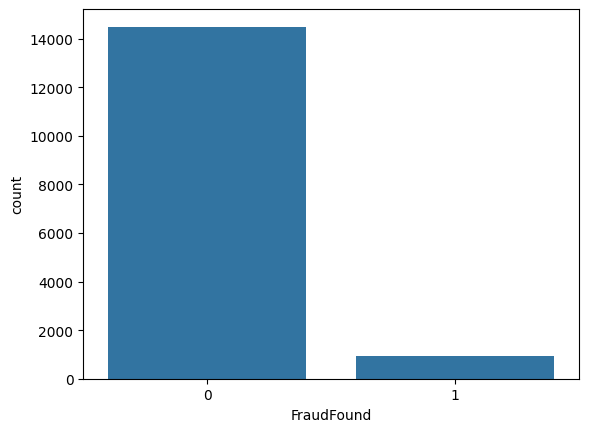

In [ ]:
sns.countplot(x='FraudFound', data=df)
plt.show()

In [ ]:
df.describe()

,WeekOfMonth,WeekOfMonthClaimed,Age,Deductible,DriverRating,Year,FraudFound
count,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,2.788586,2.693969,39.855707,407.704280,2.487808,1994.866472,0.059857
std,1.287585,1.259115,13.492377,43.950998,1.119453,0.803313,0.237230
min,1.000000,1.000000,0.000000,300.000000,1.000000,1994.000000,0.000000
25%,2.000000,2.000000,31.000000,400.000000,1.000000,1994.000000,0.000000
50%,3.000000,3.000000,38.000000,400.000000,2.000000,1995.000000,0.000000
75%,4.000000,4.000000,48.000000,400.000000,3.000000,1996.000000,0.000000
max,5.000000,5.000000,80.000000,700.000000,4.000000,1996.000000,1.000000


In [ ]:
df[df['Age'] == 0]['Age'].value_counts()

,count
Age,
0,320


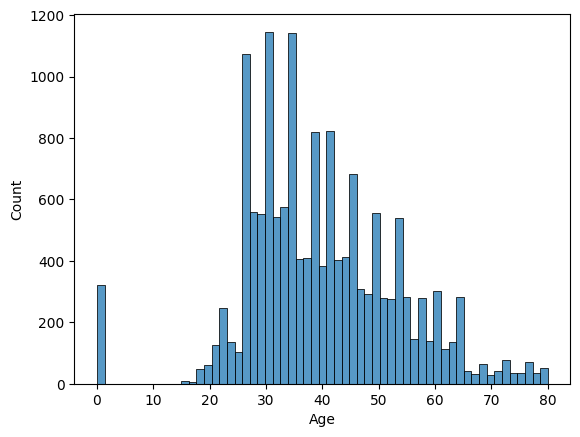

In [ ]:
sns.histplot(df['Age'])
plt.show()

In [ ]:
df.loc[df['Age'] == 0, 'Age'] = df['Age'].median()

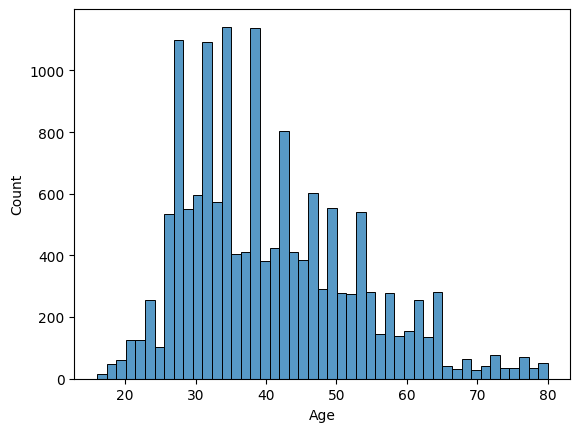

In [ ]:
sns.histplot(df['Age'])
plt.show()

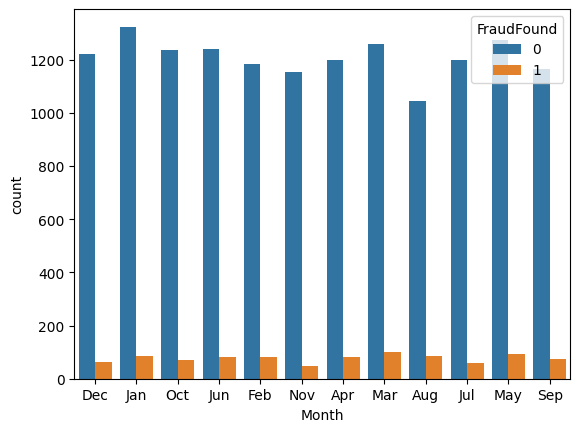

In [ ]:
sns.countplot(x='Month', data=df, hue= 'FraudFound')
plt.show()

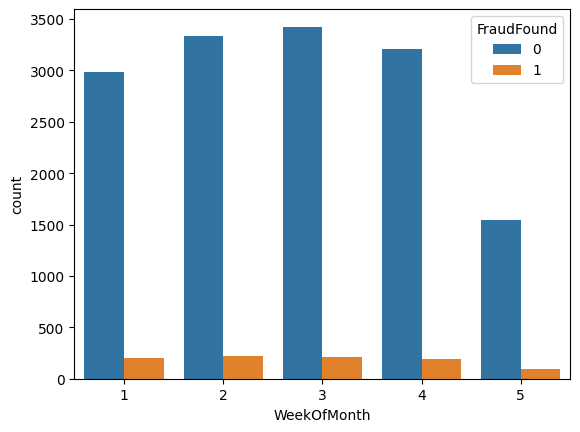

In [ ]:
sns.countplot(x='WeekOfMonth', data=df, hue= 'FraudFound')
plt.show()

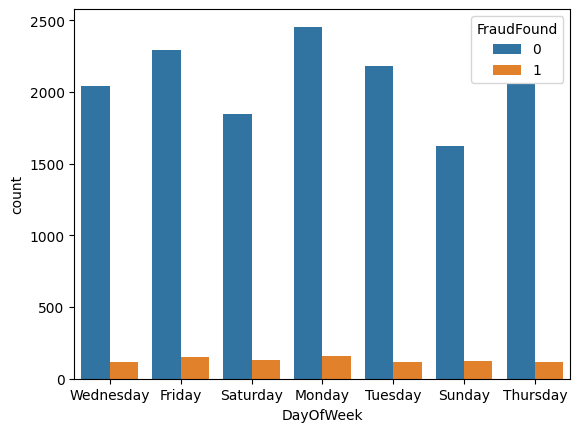

In [ ]:
sns.countplot(x='DayOfWeek', data=df, hue= 'FraudFound')
plt.show()

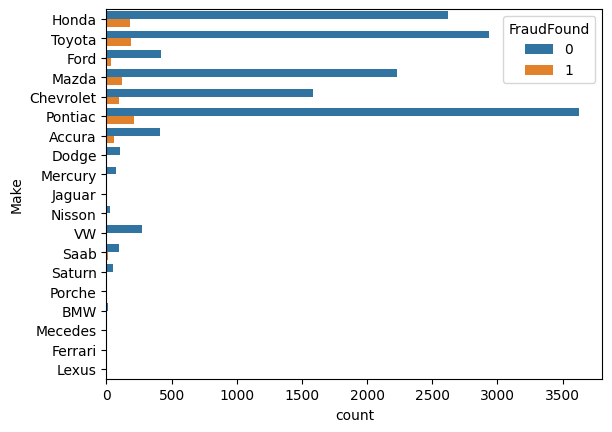

In [ ]:
sns.countplot(y='Make', data=df, hue= 'FraudFound')
plt.show()

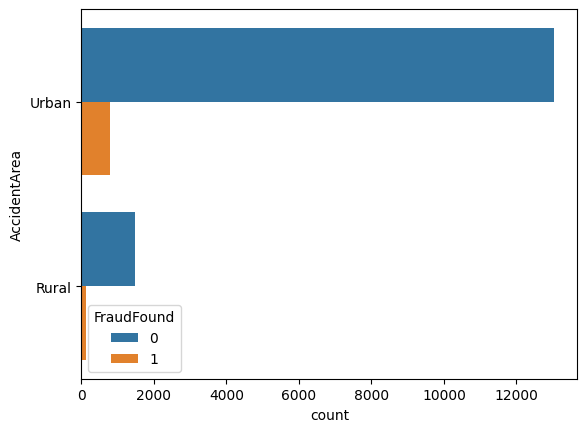

In [ ]:
sns.countplot(y='AccidentArea', data=df, hue= 'FraudFound')
plt.show()

In [ ]:
df['DayOfWeekClaimed'].value_counts()

,count
DayOfWeekClaimed,
Monday,3757
Tuesday,3375
Wednesday,2951
Thursday,2660
Friday,2497
Saturday,127
Sunday,52
0,1


In [ ]:
mode_day = df.loc[df['DayOfWeekClaimed'] != 0, 'DayOfWeekClaimed'].mode()[0]

df['DayOfWeekClaimed'] = df['DayOfWeekClaimed'].replace('0', mode_day)


In [ ]:
mode_day

'Monday'

In [ ]:
df['DayOfWeekClaimed'].value_counts()

,count
DayOfWeekClaimed,
Monday,3758
Tuesday,3375
Wednesday,2951
Thursday,2660
Friday,2497
Saturday,127
Sunday,52


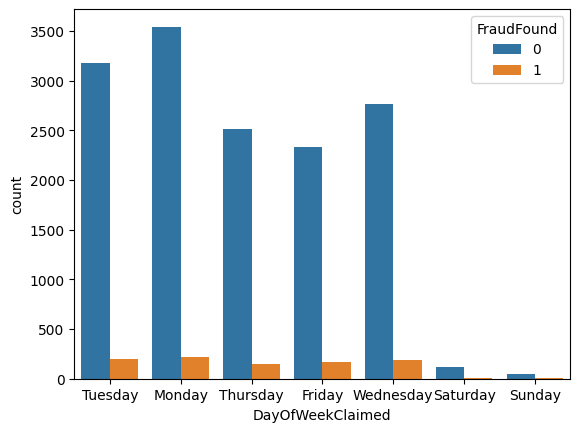

In [ ]:
sns.countplot(x='DayOfWeekClaimed', data=df, hue= 'FraudFound')
plt.show()

In [ ]:
df['MonthClaimed'].value_counts()

,count
MonthClaimed,
Jan,1446
May,1411
Mar,1348
Oct,1339
Jun,1293
Feb,1287
Nov,1285
Apr,1271
Sep,1242


In [ ]:
df['MonthClaimed'] = df['MonthClaimed'].replace('0', 'Jan')

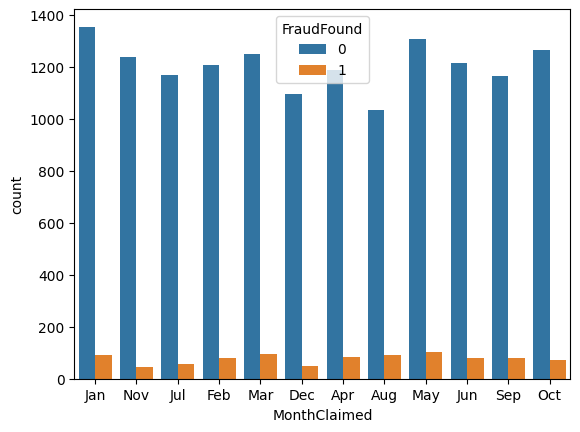

In [ ]:
sns.countplot(x='MonthClaimed', data=df, hue= 'FraudFound')
plt.show()

In [ ]:
df['WeekOfMonthClaimed'].value_counts()

,count
WeekOfMonthClaimed,
2,3720
3,3583
1,3450
4,3433
5,1234


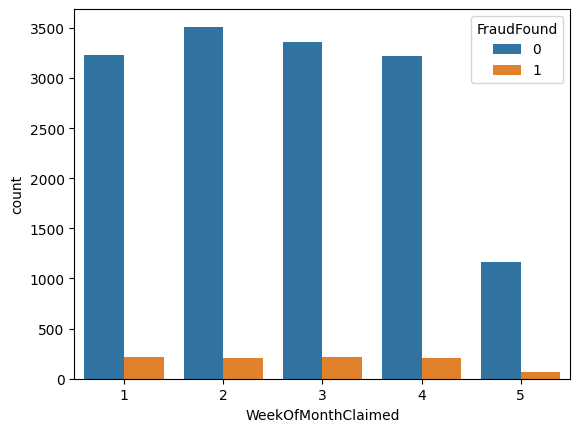

In [ ]:
sns.countplot(x='WeekOfMonthClaimed', data=df, hue= 'FraudFound')
plt.show()

In [ ]:
df.columns

Index(['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea',
       'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex',
       'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory',
       'VehiclePrice', 'Deductible', 'DriverRating', 'Days:Policy-Accident',
       'Days:Policy-Claim', 'PastNumberOfClaims', 'AgeOfVehicle',
       'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType',
       'NumberOfSuppliments', 'AddressChange-Claim', 'NumberOfCars', 'Year',
       'BasePolicy', 'FraudFound'],
      dtype='object')

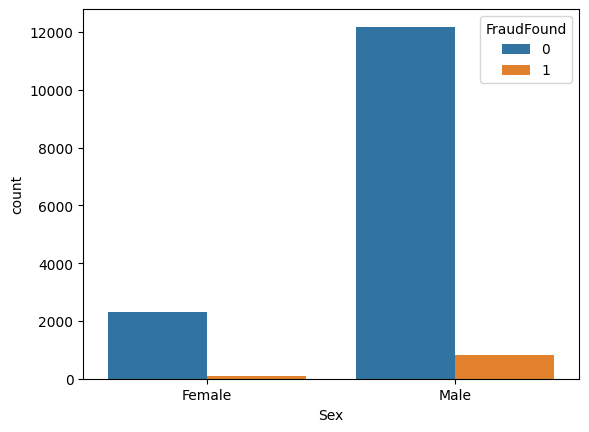

In [ ]:
sns.countplot(x='Sex', data=df, hue= 'FraudFound')
plt.show()

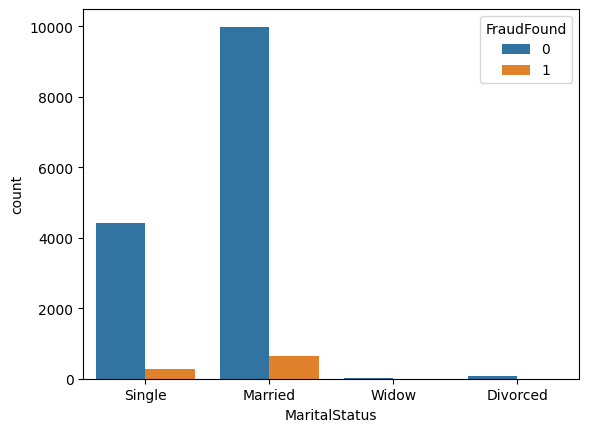

In [ ]:
sns.countplot(x='MaritalStatus', data=df, hue= 'FraudFound')
plt.show()

In [ ]:
df['Fault'].value_counts()

,count
Fault,
Policy Holder,11230
Third Party,4190


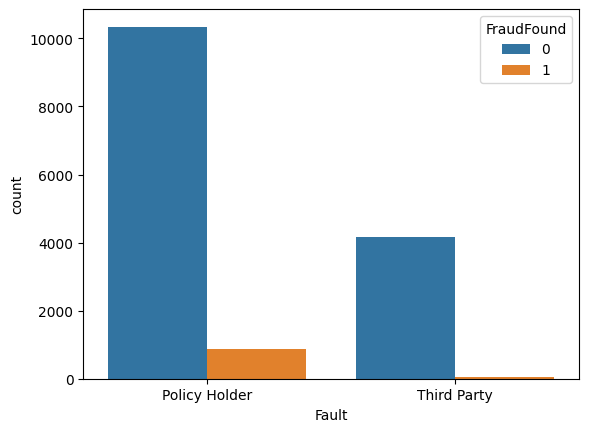

In [ ]:
sns.countplot(x='Fault', data=df, hue= 'FraudFound')
plt.show()

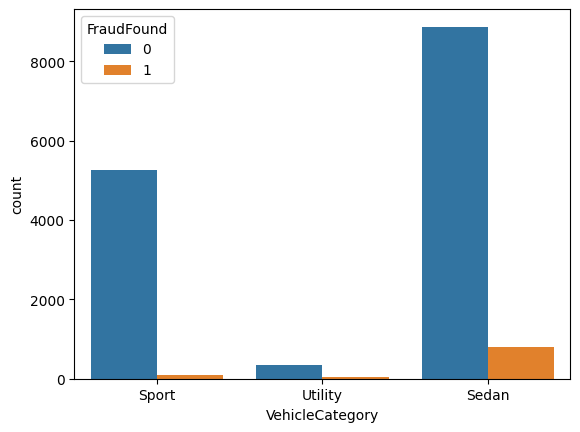

In [ ]:
sns.countplot(x='VehicleCategory', data=df, hue= 'FraudFound')
plt.show()

In [ ]:
df['VehiclePrice'].value_counts()

,count
VehiclePrice,
"20,000 to 29,000",8079
"30,000 to 39,000",3533
"more than 69,000",2164
"less than 20,000",1096
"40,000 to 59,000",461
"60,000 to 69,000",87


In [ ]:
price_map = {
    'less than 20,000': 'Very_Low',
    '20,000 to 29,000': 'Low',
    '30,000 to 39,000': 'Lower_Mid',
    '40,000 to 59,000': 'Mid',
    '60,000 to 69,000': 'Upper_Mid',
    'more than 69,000': 'High'
}

df['VehiclePriceCategory'] = (
    df['VehiclePrice']
    .map(price_map)
    .astype('category')
)


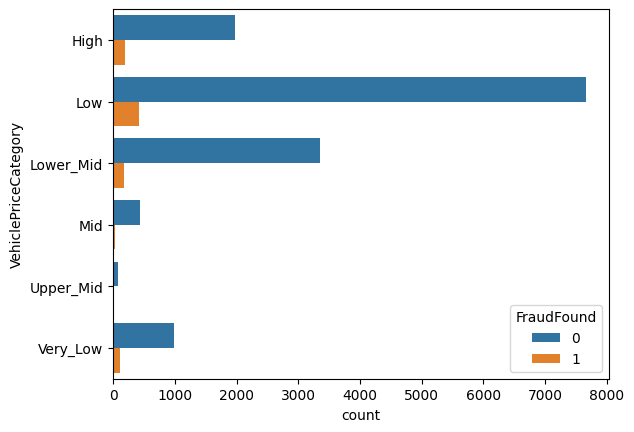

In [ ]:
sns.countplot(y='VehiclePriceCategory', data=df, hue= 'FraudFound')
plt.show()

In [ ]:
df['AgeOfVehicle'].value_counts()

,count
AgeOfVehicle,
7 years,5807
more than 7,3981
6 years,3448
5 years,1357
new,373
4 years,229
3 years,152
2 years,73


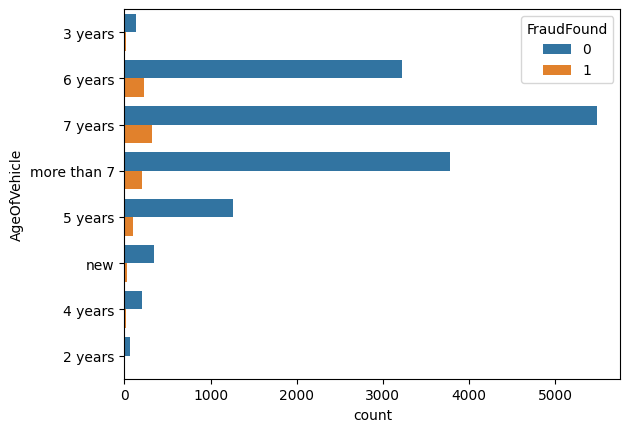

In [ ]:
sns.countplot(y='AgeOfVehicle', data=df, hue= 'FraudFound')
plt.show()

In [ ]:
df['AgeOfPolicyHolder'].value_counts()

,count
AgeOfPolicyHolder,
31 to 35,5593
36 to 40,4043
41 to 50,2828
51 to 65,1392
26 to 30,613
over 65,508
16 to 17,320
21 to 25,108
18 to 20,15


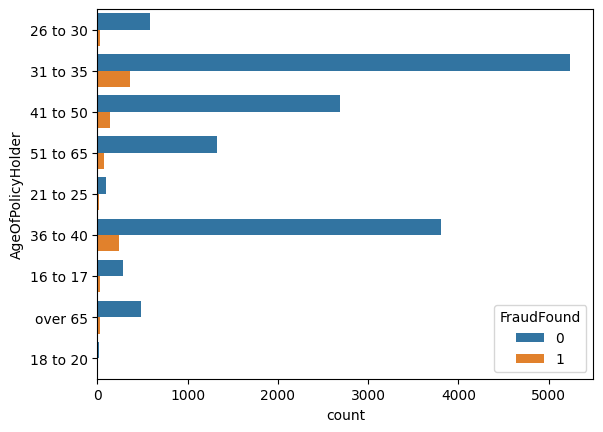

In [ ]:
sns.countplot(y='AgeOfPolicyHolder', data=df, hue= 'FraudFound')
plt.show()

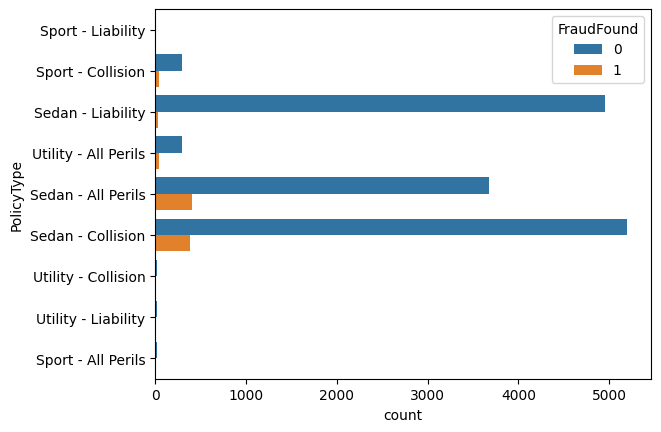

In [ ]:
sns.countplot(y='PolicyType', data=df, hue= 'FraudFound')
plt.show()

In [ ]:
df['Deductible'].value_counts()

,count
Deductible,
400,14838
700,311
500,263
300,8


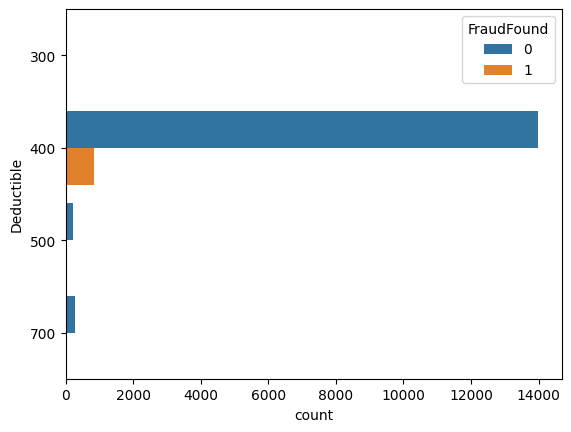

In [ ]:
sns.countplot(y='Deductible', data=df, hue= 'FraudFound')
plt.show()

In [ ]:
df.columns

Index(['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea',
       'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex',
       'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory',
       'VehiclePrice', 'Deductible', 'DriverRating', 'Days:Policy-Accident',
       'Days:Policy-Claim', 'PastNumberOfClaims', 'AgeOfVehicle',
       'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType',
       'NumberOfSuppliments', 'AddressChange-Claim', 'NumberOfCars', 'Year',
       'BasePolicy', 'FraudFound', 'VehiclePriceCategory'],
      dtype='object')

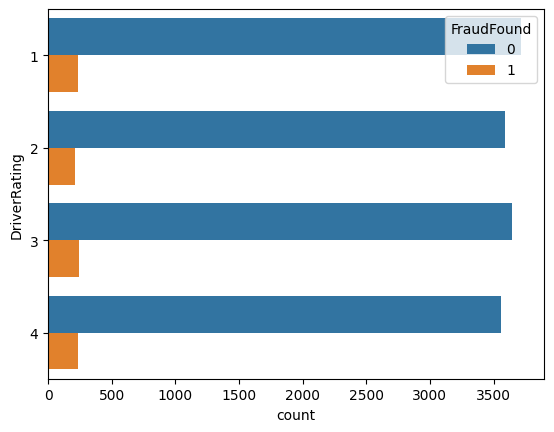

In [ ]:
sns.countplot(y='DriverRating', data=df, hue= 'FraudFound')
plt.show()

In [ ]:
df['Days:Policy-Accident'].value_counts()

,count
Days:Policy-Accident,
more than 30,15247
none,55
8 to 15,55
15 to 30,49
1 to 7,14


In [ ]:
mode_value = df['Days:Policy-Accident'].mode()[0]
df['Days:Policy-Accident'] = df['Days:Policy-Accident'].replace('none', mode_value)

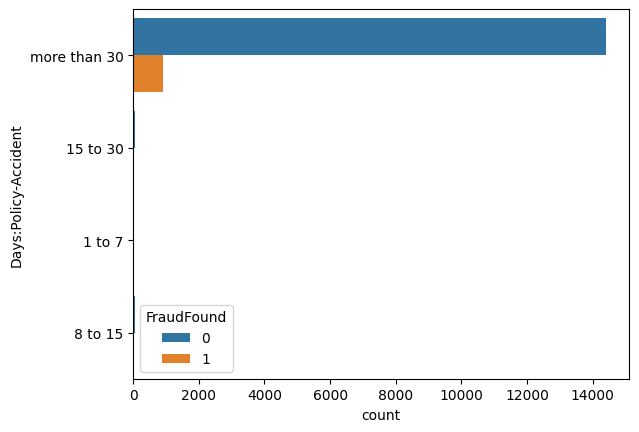

In [ ]:
sns.countplot(y='Days:Policy-Accident', data=df, hue= 'FraudFound')
plt.show()

In [ ]:
df['Days:Policy-Claim'].value_counts()

,count
Days:Policy-Claim,
more than 30,15342
15 to 30,56
8 to 15,21
none,1


In [ ]:
mode_value = df['Days:Policy-Claim'].mode()[0]
df['Days:Policy-Claim'] = df['Days:Policy-Claim'].replace('none', mode_value)

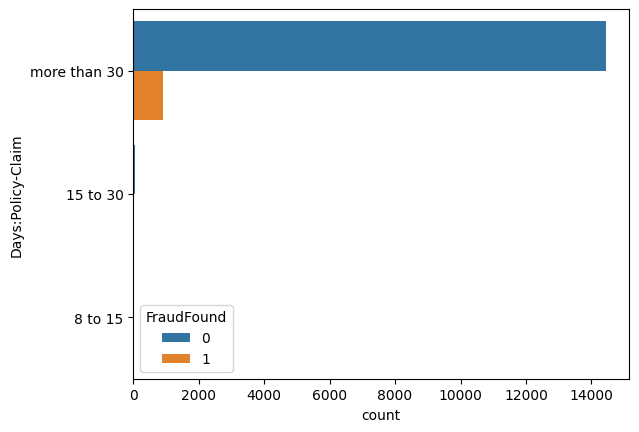

In [ ]:
sns.countplot(y='Days:Policy-Claim', data=df, hue= 'FraudFound')
plt.show()

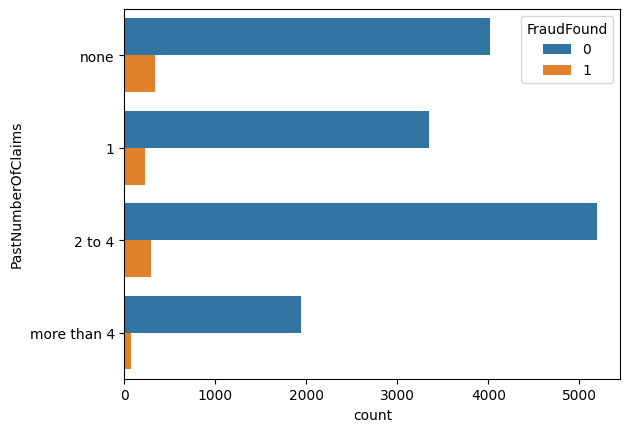

In [ ]:
sns.countplot(y='PastNumberOfClaims', data=df, hue= 'FraudFound')
plt.show()

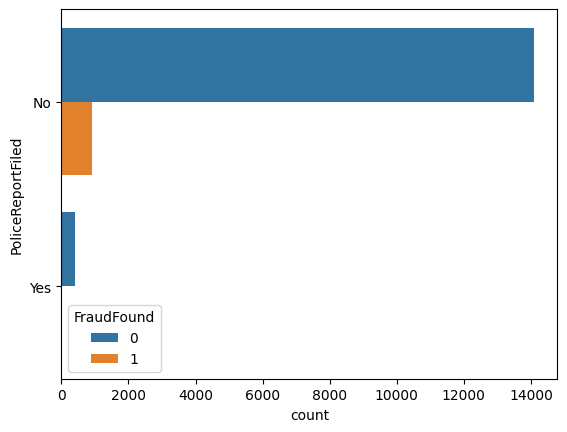

In [ ]:
sns.countplot(y='PoliceReportFiled', data=df, hue= 'FraudFound')
plt.show()
#

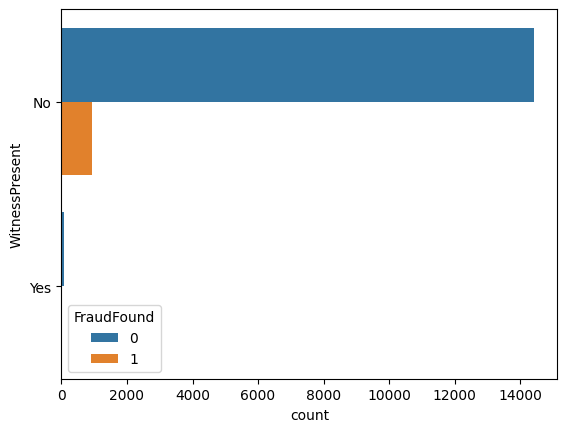

In [ ]:
sns.countplot(y='WitnessPresent', data=df, hue= 'FraudFound')
plt.show()
#

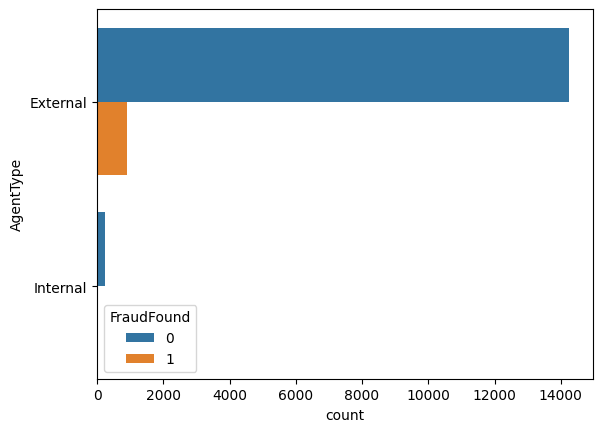

In [ ]:
sns.countplot(y='AgentType', data=df, hue= 'FraudFound')
plt.show()
#

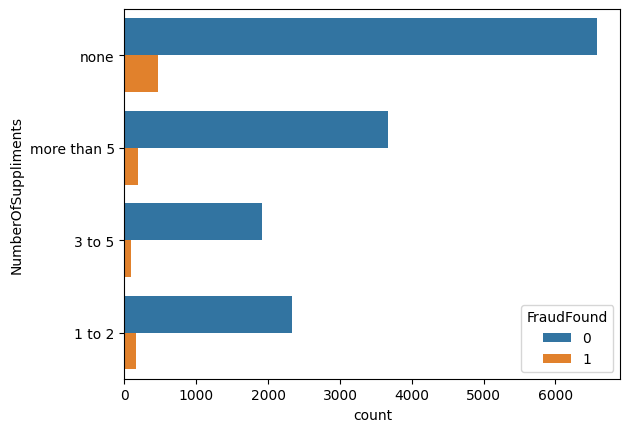

In [ ]:
sns.countplot(y='NumberOfSuppliments', data=df, hue= 'FraudFound')
plt.show()
#

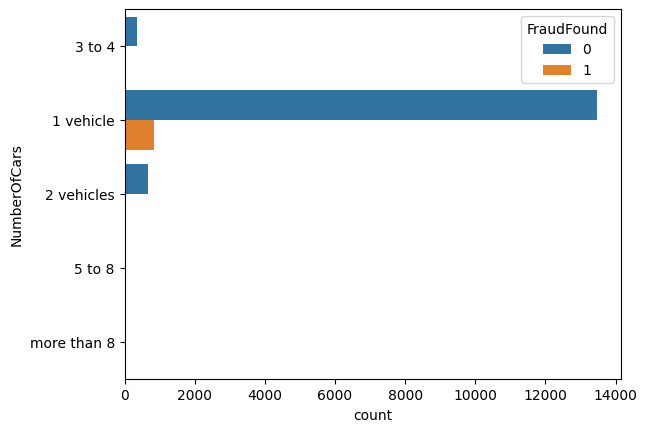

In [ ]:
sns.countplot(y='NumberOfCars', data=df, hue= 'FraudFound')
plt.show()
#

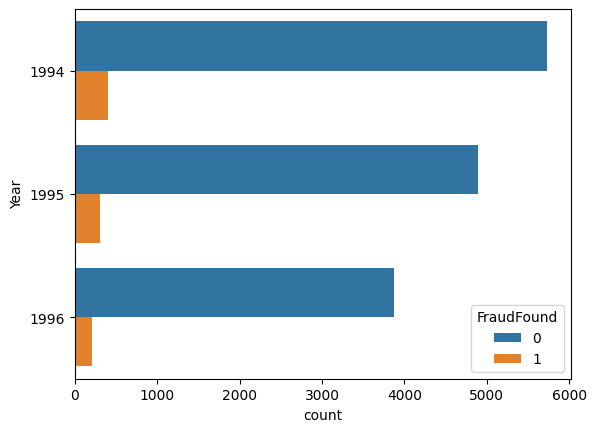

In [ ]:
sns.countplot(y='Year', data=df, hue= 'FraudFound')
plt.show()
#

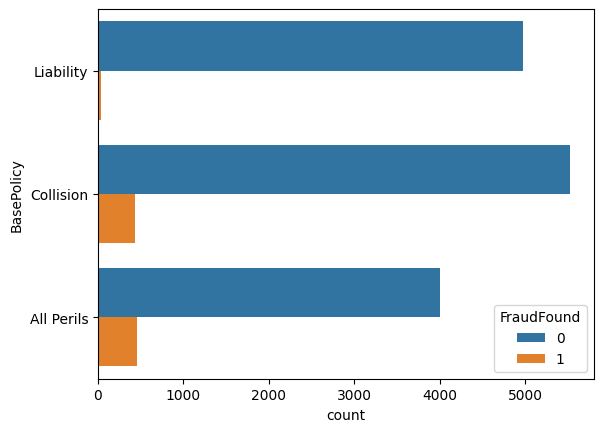

In [ ]:
sns.countplot(y='BasePolicy', data=df, hue= 'FraudFound')
plt.show()
#

In [ ]:
df.columns

Index(['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea',
       'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex',
       'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory',
       'VehiclePrice', 'Deductible', 'DriverRating', 'Days:Policy-Accident',
       'Days:Policy-Claim', 'PastNumberOfClaims', 'AgeOfVehicle',
       'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType',
       'NumberOfSuppliments', 'AddressChange-Claim', 'NumberOfCars', 'Year',
       'BasePolicy', 'FraudFound', 'VehiclePriceCategory'],
      dtype='object')

In [ ]:
df.drop(columns=['VehiclePrice'], inplace = True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Month                 15420 non-null  object  
 1   WeekOfMonth           15420 non-null  int64   
 2   DayOfWeek             15420 non-null  object  
 3   Make                  15420 non-null  object  
 4   AccidentArea          15420 non-null  object  
 5   DayOfWeekClaimed      15420 non-null  object  
 6   MonthClaimed          15420 non-null  object  
 7   WeekOfMonthClaimed    15420 non-null  int64   
 8   Sex                   15420 non-null  object  
 9   MaritalStatus         15420 non-null  object  
 10  Age                   15420 non-null  int64   
 11  Fault                 15420 non-null  object  
 12  PolicyType            15420 non-null  object  
 13  VehicleCategory       15420 non-null  object  
 14  Deductible            15420 non-null  int64   
 15  Dr

In [ ]:
df.to_csv('cleaned_data.csv', index=False)

## Preprocessing

In [ ]:
df[['BasePolicy', 'PolicyType']]

,BasePolicy,PolicyType
0,Liability,Sport - Liability
1,Collision,Sport - Collision
2,Collision,Sport - Collision
3,Liability,Sedan - Liability
4,Collision,Sport - Collision
...,...,...
15415,Collision,Sedan - Collision
15416,Liability,Sedan - Liability
15417,Collision,Sedan - Collision
15418,All Perils,Sedan - All Perils


In [ ]:
# Separate features and target
X = df.drop('FraudFound', axis=1)
y = df['FraudFound']

print(f"Fraud ratio: {y.mean():.2%}")

Fraud ratio: 5.99%


In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Identify categorical columns (excluding the new VehiclePriceCategory)
categorical_cols = cat_cols.tolist()
if 'VehiclePriceCategory' in df.columns:
    categorical_cols.append('VehiclePriceCategory')

# Label encode for tree-based models
X_encoded = X.copy()
label_encoders = {}

for col in categorical_cols:
    if col in X_encoded.columns:
        le = LabelEncoder()
        X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
        label_encoders[col] = le

# One-hot encode for linear models (optional)
X_onehot = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [ ]:
X_encoded

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,Age,Fault,PolicyType,VehicleCategory,VehiclePrice,Deductible,DriverRating,Days:Policy-Accident,Days:Policy-Claim,PastNumberOfClaims,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange-Claim,NumberOfCars,Year,BasePolicy,VehiclePriceCategory
0,2,5,6,6,1,5,4,1,0,2,21,0,5,1,5,300,1,3,2,3,1,3,0,0,0,3,0,2,1994,2,0
1,4,3,6,6,1,1,4,4,1,2,34,0,4,1,5,400,4,3,2,3,4,4,1,0,0,3,3,0,1994,1,0
2,10,5,0,6,1,4,9,2,1,1,47,0,4,1,5,400,3,3,2,0,5,6,0,0,0,3,3,0,1994,1,0
3,6,2,2,17,0,0,5,1,1,1,65,1,2,1,0,400,2,3,2,0,6,7,1,0,0,2,3,0,1994,2,1
4,4,5,1,6,1,5,3,2,0,2,27,1,4,1,5,400,1,3,2,3,3,4,0,0,0,3,3,0,1994,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15415,9,4,0,17,1,5,9,5,1,1,35,0,1,0,0,400,4,3,2,1,4,4,0,0,0,3,3,0,1996,1,1
15416,9,5,4,13,1,0,2,1,1,1,30,0,2,1,1,400,3,3,2,2,4,4,0,0,0,2,3,2,1996,2,2
15417,9,5,4,17,0,0,2,1,1,2,24,0,1,0,0,400,4,3,2,2,3,3,0,0,0,0,3,0,1996,1,1
15418,2,1,1,17,1,4,2,2,0,1,34,1,0,0,0,400,4,3,2,3,0,4,0,0,0,2,3,0,1996,0,1


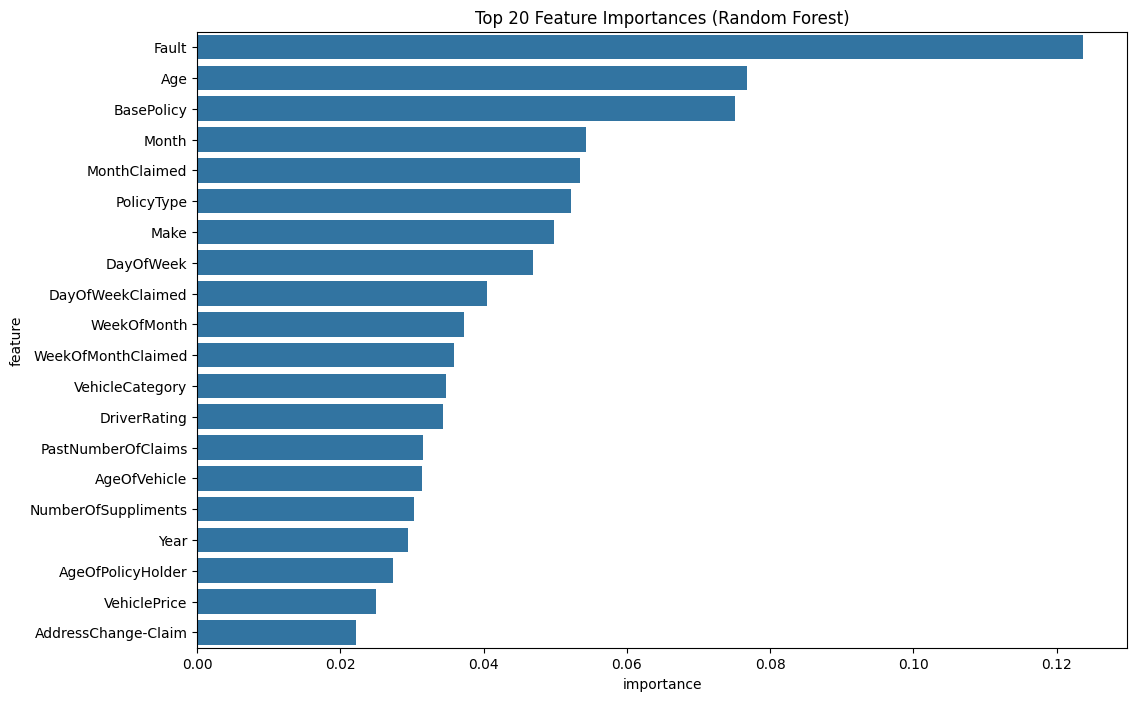

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, chi2, f_classif
import numpy as np

# Random Forest Feature Importance
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_encoded, y)

feature_importance = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance.head(20))
plt.title('Top 20 Feature Importances (Random Forest)')
plt.show()

# Select top features
top_features = feature_importance.head(15)['feature'].tolist()

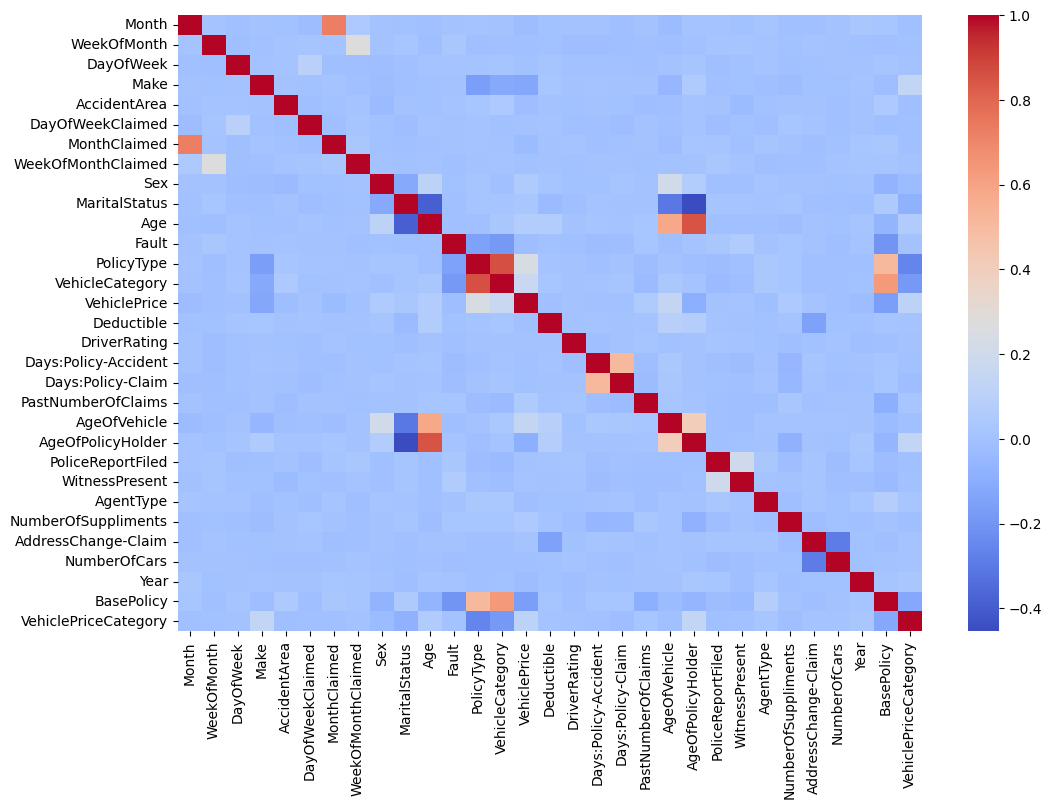

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(X_encoded.corr(), cmap ='coolwarm')
plt.show()